# Cálculo de VaR con TimeGAN y Simulación de Monte Carlo

Este notebook implementa un flujo completo para:
1. Cargar y preprocesar datos históricos de precios de acciones
2. Entrenar un modelo TimeGAN
3. Generar datos sintéticos futuros
4. Calcular el VaR mediante simulación de Monte Carlo

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf

# Añadir el directorio raíz al path
sys.path.append(os.path.abspath('..'))

# Importar módulos del proyecto
from src.data.loader import load_stock_data, check_data_quality
from src.data.transform import calculate_returns, add_features, normalize_data, inverse_normalize, build_multi_asset_portfolio
from src.data.windowing import create_windows, recreate_time_series
from src.models.timegan import timegan_init, timegan_train, timegan_export_generator, generator_gen, generator_save, generator_load
from src.models.var_model import monte_carlo_var, parametric_var, historical_var
from src.utils.evaluation import calculate_kl_divergence, discriminative_score, predictive_score, visualize_tsne
from src.utils.visualization import plot_stock_prices, plot_returns_distribution, plot_acf_comparison, plot_var_histogram, plot_multiple_var_methods, plot_synthetic_returns

# Configurar semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

2025-05-01 04:27:57.912923: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-01 04:27:58.610192: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 1. Descargar y Preprocesar Datos

En la tupla `tickers` meta los tickers de los activos que quiere incluir en el portafolio y que se encuentren en yahoo finance y en la tupla `weights` meta los pesos que tienen en su portafolio. En este caso vamos a usar una estrategia naive muy basica para exponernos al mercado estadounidense y europeo.

In [2]:
h = build_multi_asset_portfolio(("^GSPC", "AGG", "DBC", "GLD"), (0.5, 0.3, 0.1, 0.1))

Descargando datos históricos para 4 activos...
  ✓ ^GSPC: 24448 registros desde 1927-12-30 00:00:00 hasta 2025-04-30 00:00:00
  ✓ AGG: 5432 registros desde 2003-09-29 00:00:00 hasta 2025-04-30 00:00:00
  ✓ DBC: 4839 registros desde 2006-02-06 00:00:00 hasta 2025-04-30 00:00:00
  ✓ GLD: 5144 registros desde 2004-11-18 00:00:00 hasta 2025-04-30 00:00:00
Fecha de inicio común: 2006-02-06 00:00:00
  ✓ ^GSPC: 4839 registros después del filtrado
  ✓ AGG: 4839 registros después del filtrado
  ✓ DBC: 4839 registros después del filtrado
  ✓ GLD: 4839 registros después del filtrado
Portafolio creado exitosamente con 4839 observaciones
Período del portafolio: 2006-02-06 00:00:00 a 2025-04-30 00:00:00


<Axes: xlabel='Date', ylabel='Close'>

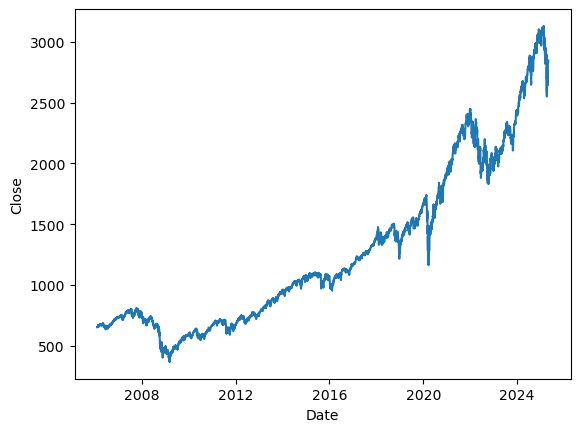

In [3]:
sns.lineplot(x="Date", y="Close", data=h)

In [4]:
# Calcular rendimientos y añadir características
df = calculate_returns(h, method='log')
df = add_features(df, window_sizes=[5, 10, 20])

# Visualizar los retornos
df

,Date,Close,Returns,MA_5,Volatility_5,Return_5,MA_10,Volatility_10,Return_10,MA_20,Volatility_20,Return_20
20,2006-03-07,661.842119,-0.001827,666.242876,0.005424,-0.003985,667.384486,0.005734,-0.005518,663.896050,0.005703,0.007668
21,2006-03-08,663.017112,0.001774,664.891444,0.003186,-0.010140,666.648034,0.005127,-0.011046,664.477643,0.005332,0.017700
22,2006-03-09,659.921328,-0.004680,663.119492,0.003365,-0.013336,665.854655,0.005187,-0.011951,664.632372,0.005168,0.004700
23,2006-03-10,664.473827,0.006875,662.461299,0.005498,-0.004941,665.418119,0.005747,-0.006548,665.053326,0.005362,0.012751
24,2006-03-13,665.931354,0.002191,663.037148,0.004379,0.004333,664.904289,0.005670,-0.007686,665.477360,0.005363,0.012817
...,...,...,...,...,...,...,...,...,...,...,...,...
4834,2025-04-24,2804.796010,0.019832,2721.258803,0.019155,0.038024,2726.709500,0.020492,0.005845,2747.434426,0.031139,-0.038714
4835,2025-04-25,2824.792981,0.007104,2745.525380,0.018844,0.043903,2739.742308,0.016447,0.047235,2743.352611,0.031202,-0.028490
4836,2025-04-28,2827.066002,0.000804,2782.546161,0.009485,0.067718,2748.181115,0.015818,0.030305,2742.175078,0.030915,-0.008296
4837,2025-04-29,2842.850039,0.005568,2809.844592,0.007808,0.049203,2756.067608,0.015761,0.028134,2740.989203,0.030915,-0.008308


In [5]:
# Normalizar los datos para el entrenamiento del modelo
features_to_normalize = [col for col in df.columns if col != 'Close']
df_norm, norm_params = normalize_data(df, features=features_to_normalize, method='minmax')

# Visualizar datos normalizados
df_norm.head()

,Date,Close,Returns,MA_5,Volatility_5,Return_5,MA_10,Volatility_10,Return_10,MA_20,Volatility_20,Return_20
20,0.000000,661.842119,0.532054,0.106034,0.053496,0.528097,0.104206,0.060647,0.601115,0.098396,0.064817,0.658406
21,0.000143,663.017112,0.547848,0.105541,0.029263,0.510996,0.103936,0.052176,0.589398,0.098612,0.058395,0.676339
22,0.000286,659.921328,0.519535,0.104896,0.031203,0.502116,0.103644,0.053013,0.587482,0.098670,0.055554,0.653100
23,0.000429,664.473827,0.570227,0.104656,0.054296,0.525443,0.103483,0.060826,0.598932,0.098826,0.058916,0.667493
24,0.000858,665.931354,0.549679,0.104866,0.042178,0.551209,0.103294,0.059753,0.596520,0.098983,0.058933,0.667610


In [6]:
# Crear ventanas temporales para el entrenamiento
window_size = 250  # un año de datos históricos
stride = 1       # Avanzar de 1 en 1 día para crear ventanas

# Seleccionar características para el modelo
selected_features = ['Returns']
windows = create_windows(df_norm[selected_features], window_size=window_size, stride=stride)

print(f"Forma de las ventanas de entrenamiento: {windows.shape}")

Forma de las ventanas de entrenamiento: (4570, 250, 1)


## 2. Entrenar el Modelo TimeGAN

2025-05-01 04:28:03.348550: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 04:28:03.435602: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 04:28:03.435694: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 04:28:03.440522: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 04:28:03.440607: I external/local_xla/xla/stream_executor

Verificando estadísticas de los conjuntos:
Train - Media: 0.5413, Desv. Est.: 0.0542
Test - Media: 0.5418, Desv. Est.: 0.0457
train autoencoder


100%|██████████| 10/10 [00:03<00:00,  2.71it/s]


train supervisor


100%|██████████| 10/10 [00:02<00:00,  4.50it/s]


joint train


100%|██████████| 10/10 [00:24<00:00,  2.46s/it]


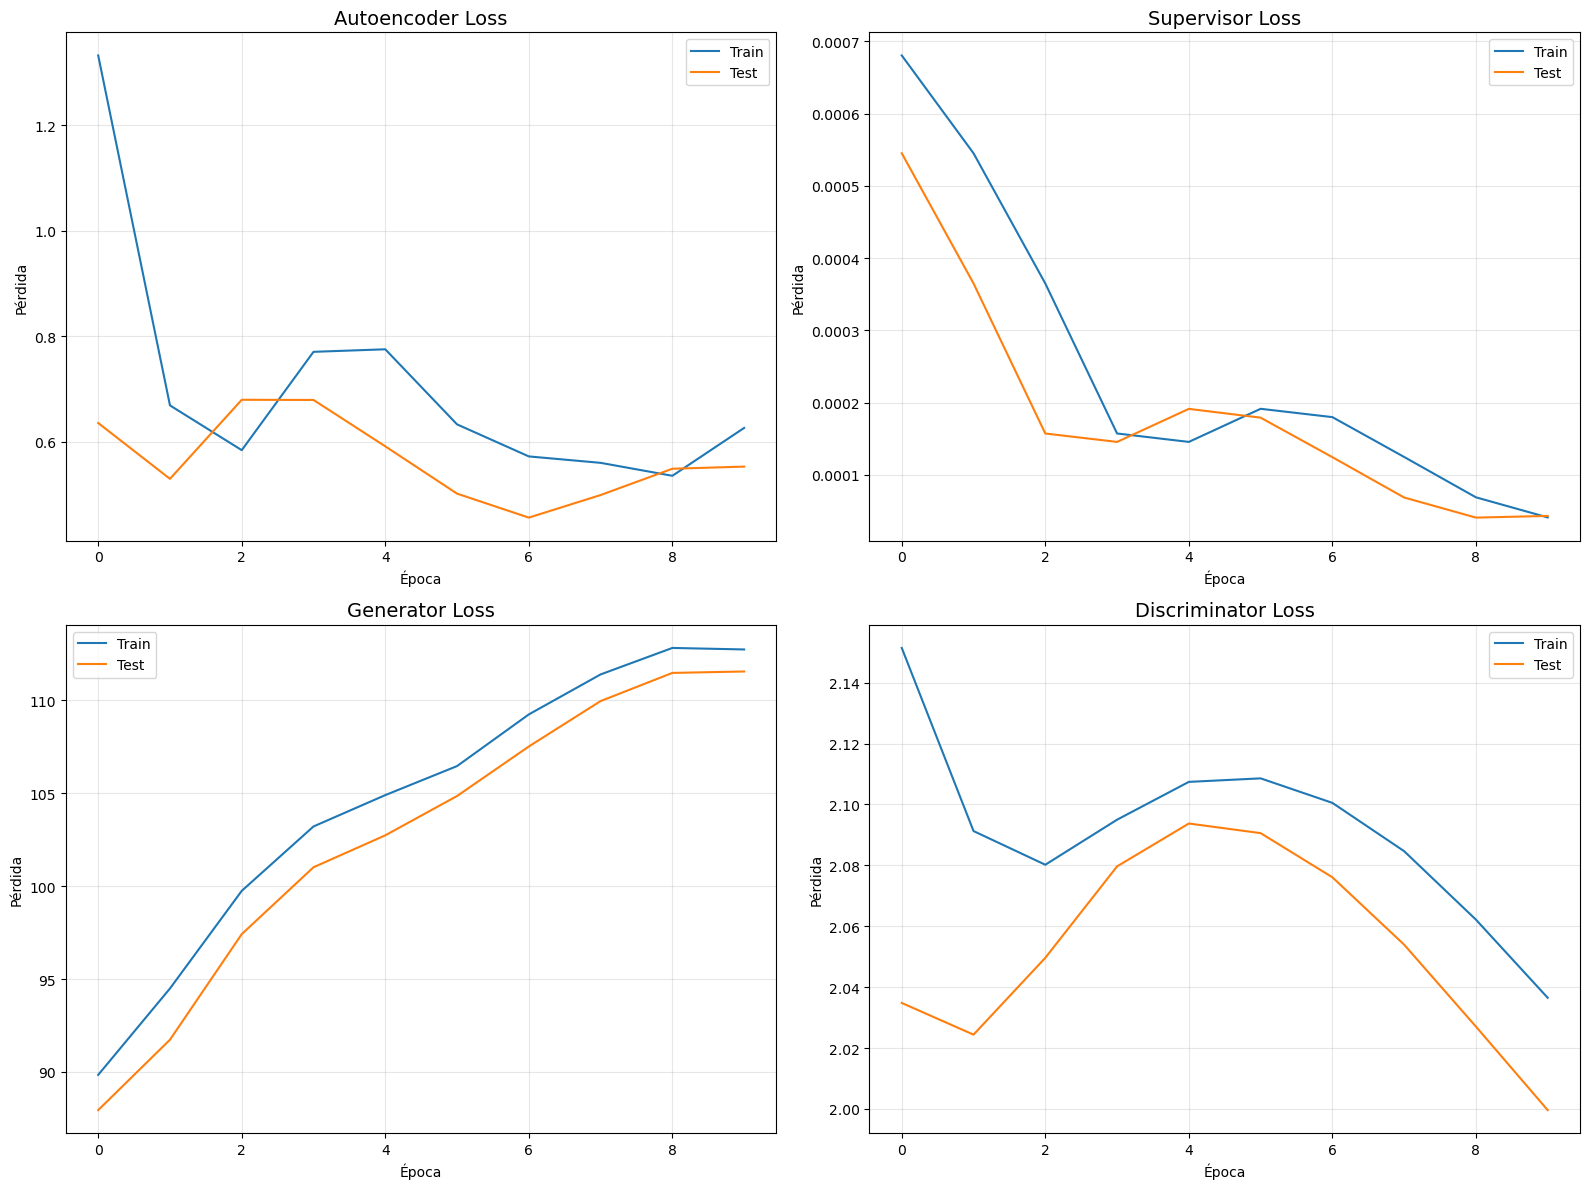


Propiedades estadísticas después del entrenamiento:
Datos reales - Media: 0.5416, Desv. Est.: 0.0553
Datos generados - Media: 0.5308, Desv. Est.: 0.0010


In [ ]:
# Definir parámetros del modelo
time_series_len = window_size
features = len(selected_features)
rnn_units = 16   # Unidades en cada capa GRU
rnn_layers = 3   # Número de capas GRU

# Inicializar el modelo TimeGAN
timegan_tuple = timegan_init(time_series_len, features, rnn_units, rnn_layers)

# Parámetros de entrenamiento
epochs = 50      # Reducido para demostración, usar 1000-2000 para resultados óptimos
batch_size = 64
learning_rate = 0.005

# Entrenar el modelo (esto puede tomar tiempo)
trained_timegan = timegan_train(windows, timegan_tuple, epochs, batch_size, learning_rate)

# Exportar el generador
syn_generator = timegan_export_generator(trained_timegan)

# Guardar el modelo entrenado
os.makedirs('../models', exist_ok=True)
generator_save(syn_generator, '../models/timegan_stock_model.weights.h5')

## 3. Generar Datos Sintéticos y Evaluar

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
[[0.52858937]
 [0.5389438 ]
 [0.54114974]
 [0.5410027 ]
 [0.5404557 ]
 [0.5400386 ]
 [0.53987944]
 [0.53995717]
 [0.5401977 ]
 [0.5405333 ]
 [0.5408895 ]
 [0.54121107]
 [0.54147494]
 [0.5416861 ]
 [0.54183394]
 [0.5419297 ]
 [0.5419957 ]
 [0.5420386 ]
 [0.5420582 ]
 [0.54206514]
 [0.5420647 ]
 [0.5420549 ]
 [0.54204464]
 [0.54203266]
 [0.5420186 ]
 [0.54200476]
 [0.5419843 ]
 [0.54197377]
 [0.5419629 ]
 [0.54194766]
 [0.5419383 ]
 [0.5419315 ]
 [0.5419259 ]
 [0.5419137 ]
 [0.54190063]
 [0.5418949 ]
 [0.54189545]
 [0.54188603]
 [0.5418753 ]
 [0.5418728 ]
 [0.5418716 ]
 [0.54187244]
 [0.5418689 ]
 [0.5418652 ]
 [0.5418656 ]
 [0.5418659 ]
 [0.5418633 ]
 [0.5418537 ]
 [0.5418461 ]
 [0.54184836]
 [0.54185003]
 [0.5418521 ]
 [0.54185045]
 [0.5418491 ]
 [0.5418445 ]
 [0.5418421 ]
 [0.5418401 ]
 [0.54184014]
 [0.5418442 ]
 [0.54183894]
 [0.54184014]
 [0.5418389 ]
 [0.5418418 ]
 [0.5418379 ]
 [0.5418375 ]
 [0.54183465]
 [0.54183227]
 [0.5418317 ]
 [0.54183

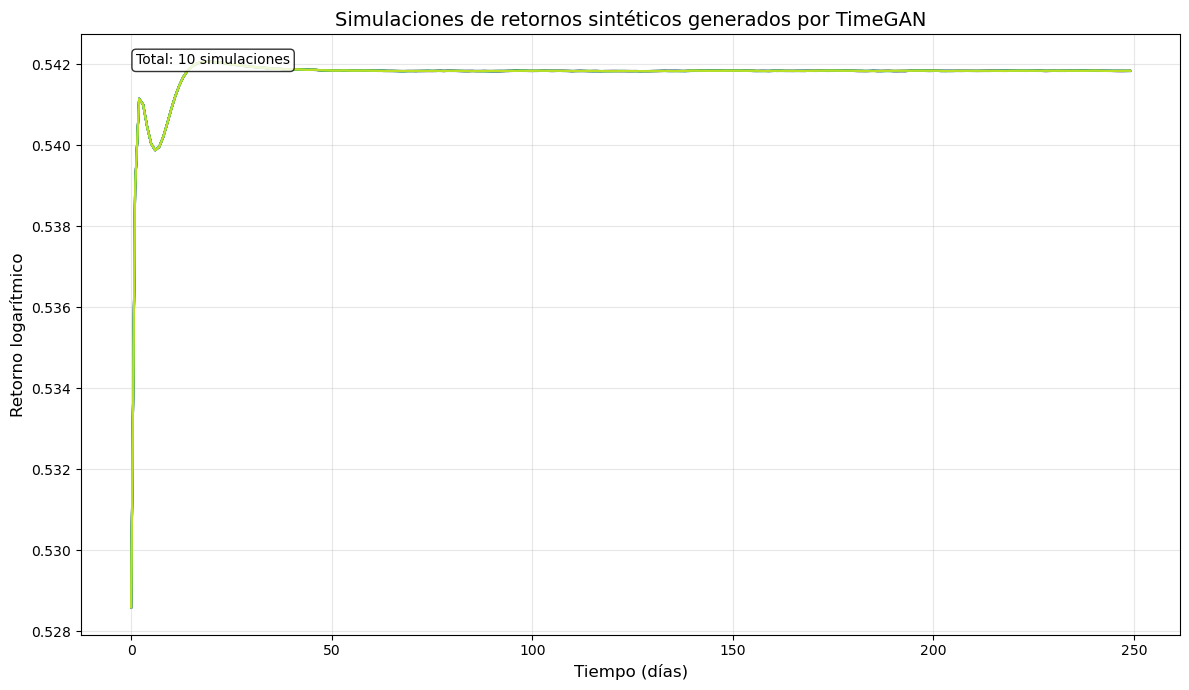

In [ ]:
# Cargar el modelo guardado (opcional, si se quiere saltar el entrenamiento)
# syn_generator = generator_load('../models/timegan_stock_model.h5', time_series_len, features, rnn_units, rnn_layers)

# Generar datos sintéticos
n_simulations = 10  # Número de trayectorias sintéticas
synthetic_windows = generator_gen(syn_generator, generate_cnt=n_simulations)

In [13]:
# Evaluar la calidad de los datos sintéticos
kl_div = calculate_kl_divergence(windows, synthetic_windows)
disc_score = discriminative_score(windows, synthetic_windows)
pred_score = predictive_score(windows, synthetic_windows)

print(f"Divergencia KL: {kl_div:.4f}")
print(f"Discriminative Score: {disc_score:.4f}")
print(f"Predictive Score (MSE): {pred_score:.4f}")

# Visualizar datos con t-SNE
tsne_fig = visualize_tsne(windows, synthetic_windows)
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [100, 4790]

## 4. Proyectar Trayectorias Futuras y Reconstruir Series de Precios

In [ ]:
# Desnormalizar las ventanas sintéticas
synthetic_df_list = []

for i in range(n_simulations):
    # Crear un DataFrame con las columnas seleccionadas
    synth_df = pd.DataFrame(synthetic_windows[i], columns=selected_features)
    
    # Desnormalizar
    synth_df = inverse_normalize(synth_df, norm_params, method='minmax')
    synthetic_df_list.append(synth_df)

# Reconstruir las series de precios a partir de los rendimientos sintéticos
last_price = df['Close'].iloc[-1]
horizon = 100  # Días futuros a proyectar

future_prices_list = []
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=horizon)

for synth_df in synthetic_df_list:
    # Usar solo los primeros 'horizon' puntos de las ventanas
    returns = synth_df['Returns'].values[:horizon]
    
    # Reconstruir precios a partir de rendimientos logarítmicos
    future_prices = [last_price]
    for ret in returns:
        future_prices.append(future_prices[-1] * np.exp(ret))
    
    future_prices = future_prices[1:]  # Eliminar el precio inicial que ya tenemos
    future_prices_list.append(future_prices)

# Visualizar trayectorias de precios históricos y sintéticos
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], 'b-', label='Precios Históricos')

for i, prices in enumerate(future_prices_list):
    if i == 0:
        plt.plot(future_dates, prices, 'r-', alpha=0.8, label='Precios Sintéticos')
    else:
        plt.plot(future_dates, prices, 'r-', alpha=0.2)

plt.title('Precios Históricos y Proyecciones Sintéticas', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Calcular el VaR mediante Simulación de Monte Carlo

In [ ]:
# Calcular el VaR a 1 día
initial_price = df['Close'].iloc[-1]
investment_amount = 100000  # Inversión de $100,000
position_size = investment_amount / initial_price  # Número de acciones

# Ajustar el VaR por el tamaño de la posición
var_mc, es_mc = monte_carlo_var(future_prices_list, initial_price, horizon=1, confidence_level=0.95)
var_mc_position = var_mc * position_size
es_mc_position = es_mc * position_size

print(f"VaR de Monte Carlo (95%) a 1 día: ${var_mc_position:.2f}")
print(f"Expected Shortfall (95%) a 1 día: ${es_mc_position:.2f}")

In [ ]:
# Comparar con otros métodos de cálculo de VaR

# Extraer rendimientos de un día para cada serie sintética
one_day_returns = [synth_df['Returns'].values[0] for synth_df in synthetic_df_list]

# VaR Paramétrico (distribución normal)
var_param_normal = parametric_var(one_day_returns, investment_amount, horizon=1, confidence_level=0.95, distribution='normal')

# VaR Paramétrico (distribución t-student)
var_param_t = parametric_var(one_day_returns, investment_amount, horizon=1, confidence_level=0.95, distribution='t-student')

# VaR Histórico
var_hist = historical_var(one_day_returns, investment_amount, confidence_level=0.95)

# Mostrar resultados
methods = ['Monte Carlo', 'Paramétrico (Normal)', 'Paramétrico (t-student)', 'Histórico']
var_values = [var_mc_position, var_param_normal, var_param_t, var_hist]

plot_multiple_var_methods(var_values, methods, title='Comparación de Métodos de VaR (95%) a 1 día')
plt.show()

## 6. Visualizar la Distribución de Pérdidas y Ganancias (P&L)

In [ ]:
# Calcular P&L para el horizonte de 1 día
one_day_prices = [prices[0] for prices in future_prices_list]
one_day_pnl = [(price - initial_price) * position_size for price in one_day_prices]

# Visualizar distribución de P&L y VaR
plot_var_histogram(one_day_pnl, var_mc_position, confidence_level=0.95, 
                   title='Distribución de P&L a 1 día y VaR (95%)')
plt.show()

## 7. Análisis de Sensibilidad del VaR

In [ ]:
# Calcular VaR para diferentes niveles de confianza
confidence_levels = [0.90, 0.95, 0.99]
var_results = []
es_results = []

for cl in confidence_levels:
    var, es = monte_carlo_var(future_prices_list, initial_price, horizon=1, confidence_level=cl)
    var_results.append(var * position_size)
    es_results.append(es * position_size)

# Visualizar resultados
plt.figure(figsize=(10, 6))
width = 0.35
ind = np.arange(len(confidence_levels))

plt.bar(ind - width/2, var_results, width, label='VaR', color='skyblue')
plt.bar(ind + width/2, es_results, width, label='Expected Shortfall', color='salmon')

plt.ylabel('USD', fontsize=12)
plt.title('VaR y Expected Shortfall por Nivel de Confianza', fontsize=14)
plt.xticks(ind, [f'{cl*100:.0f}%' for cl in confidence_levels])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores encima de las barras
for i in range(len(confidence_levels)):
    plt.text(i - width/2, var_results[i] + 50, f'${var_results[i]:.2f}', ha='center')
    plt.text(i + width/2, es_results[i] + 50, f'${es_results[i]:.2f}', ha='center')

plt.tight_layout()
plt.show()

## 8. Conclusiones

En este notebook, hemos implementado un flujo completo para:

1. Preprocesar datos históricos de precios de acciones
2. Entrenar un modelo TimeGAN para generar series temporales sintéticas
3. Proyectar trayectorias futuras de precios
4. Calcular el VaR mediante simulación de Monte Carlo y compararlo con otros métodos

Los resultados muestran que el modelo TimeGAN es capaz de generar trayectorias sintéticas que capturan las características estadísticas de los datos históricos, lo que permite una estimación más robusta del riesgo.

El VaR a 1 día calculado mediante simulación de Monte Carlo proporciona una estimación conservadora del riesgo, en línea con los métodos paramétricos e históricos, pero con la ventaja de capturar mejor las propiedades temporales de la serie.